In [1]:
import torch
import torch.nn as nn
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torch.optim as optim

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
import os
from PIL import Image

train_dir = '/home/skandan-c-y/PycharmProjects/PyTorch/data/intel-image-classification/seg_train/seg_train'
test_dir = '/home/skandan-c-y/PycharmProjects/PyTorch/data/intel-image-classification/seg_test/seg_test'
pred_dir = '/home/skandan-c-y/PycharmProjects/PyTorch/data/intel-image-classification/seg_pred'

def inspect_image(path):
    for root, _, imgs in os.walk(path):
        for img in imgs:
            if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, img)
                with Image.open(img_path) as i:
                    return i.size
    return FileNotFoundError("File with extensions `.jpg`, `.jpeg`, `.png` do now exist")

print("Inspecting image sizes")
print(f"Training dataset: {inspect_image(train_dir)}")
print(f"Testing dataset: {inspect_image(test_dir)}")
print(f"Prediction dataset: {inspect_image(pred_dir)}")

def inspect_dataset(path):
    count = 0
    for __, _, files in os.walk(path):
        for ___ in files:
            count += 1
    return count

print("\nInspecting directories")
print(f"Training dataset: {inspect_dataset(train_dir)}")
print(f"Testing dataset: {inspect_dataset(test_dir)}")
print(f"Prediction dataset: {inspect_dataset(pred_dir)}")

Inspecting image sizes
Training dataset: (150, 150)
Testing dataset: (150, 150)
Prediction dataset: (150, 150)

Inspecting directories
Training dataset: 14034
Testing dataset: 3000
Prediction dataset: 7301


In [4]:
# transforms

torch.manual_seed(28)

train_transform = v2.Compose([
    v2.Resize((150, 150)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

test_transform = v2.Compose([
    v2.Resize((150, 150)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

display_transform = v2.Compose([
    v2.Resize((150, 150)),
    v2.ToImage()
])

In [5]:
from torchvision.datasets import ImageFolder

training_dataset = ImageFolder(root=train_dir, transform=train_transform)
testing_dataset = ImageFolder(root=test_dir, transform=test_transform)

training_loader = DataLoader(
    dataset=training_dataset,
    batch_size=64,
    num_workers=6,
    shuffle=True,
    pin_memory=True,
)

testing_loader = DataLoader(
    dataset=testing_dataset,
    batch_size=64,
    num_workers=6
)

In [6]:
import math

def give_size(existing, padding, kernel, stride):
    print(math.floor((existing + 2 * padding - kernel) / stride) + 1)

## Defining NNs

In [7]:
class CNN1(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extraction = nn.Sequential(
            nn.Conv2d(          # (1, 150, 150): (3, 150, 150)
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # (32, 150, 150): (32, 75, 75)
            nn.Conv2d(            # (32, 75, 75): (64, 75, 75)
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # (64, 75, 75): (64, 37, 37)
            nn.Conv2d(           # (64, 37, 37): (128, 37, 37(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
                    # (128, 37, 37): (128, 18, 18)
        )

        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*18*18, 1024),
            nn.ReLU(),
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.clf(x)
        return x

In [8]:
class CNN2(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extraction = nn.Sequential(
            nn.Conv2d(          # (3, 150, 150): (32, 150, 150)
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(            # (32, 150, 150): (32, 150, 150)
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # (32, 150, 150): (32, 75, 75)


            nn.Conv2d(           # (32, 75, 75): (64, 75, 75)
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(           # (64, 75, 75): (64, 75, 75)
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
                    # (64, 75, 75): (64, 37, 37)

            nn.Conv2d(           # (64, 37, 37): (128, 37, 37)
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(           # (128, 37, 37): (128, 37, 37)
                in_channels=128,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
                    # (128, 37, 37): (128, 18, 18)
        )

        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*18*18, 1024),
            nn.ReLU(),
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.clf(x)
        return x

In [9]:
class CNN3(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extraction = nn.Sequential(
            nn.Conv2d(          # (1, 150, 150): (3, 150, 150)
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # (32, 150, 150): (32, 75, 75)
            nn.Conv2d(            # (32, 75, 75): (64, 75, 75)
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # (64, 75, 75): (64, 37, 37)
            nn.Conv2d(           # (64, 37, 37): (128, 37, 37(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
                    # (128, 37, 37): (128, 18, 18)
        )

        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*18*18, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.clf(x)
        return x

In [10]:
class CNN4(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extraction = nn.Sequential(
            nn.Conv2d(          # (1, 150, 150): (3, 150, 150)
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # (32, 150, 150): (32, 75, 75)
            nn.Conv2d(            # (32, 75, 75): (64, 75, 75)
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # (64, 75, 75): (64, 37, 37)
            nn.Conv2d(           # (64, 37, 37): (128, 37, 37(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
                    # (128, 37, 37): (128, 18, 18)
        )

        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*18*18, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.clf(x)
        return x

## Training & Evaluation Workflow

In [11]:
# Shared validation function (used by all models)

def validation(model, loader, criterion):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = outputs.argmax(1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy


# Generic training function — takes model, loader, criterion, optimizer
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predictions = outputs.argmax(1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

### CNN1 — Shallow baseline (single conv per block)

In [12]:
# loss & optimizer — CNN1

cnn1 = CNN1().to(device)

criterion1 = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(params=cnn1.parameters(), lr=1e-3)

print(f"CNN1 trainable params: {sum(p.numel() for p in cnn1.parameters() if p.requires_grad):,}")

CNN1 trainable params: 42,693,574


In [13]:
# metrics storage — CNN1

training_acc_1   = []
training_loss_1  = []
validation_acc_1 = []
validation_loss_1 = []

In [14]:
# training loop — CNN1

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(cnn1, training_loader, criterion1, optimizer1)
    val_loss,   val_acc   = validation(cnn1, testing_loader, criterion1)

    training_loss_1.append(train_loss)
    training_acc_1.append(train_acc)
    validation_loss_1.append(val_loss)
    validation_acc_1.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

del cnn1, criterion1, optimizer1
torch.cuda.empty_cache()

Epoch  1 | Train Loss 1.0644 | Train Acc 0.5870 | Val Loss 0.7304 | Val Acc 0.7290
Epoch  2 | Train Loss 0.6683 | Train Acc 0.7540 | Val Loss 0.6551 | Val Acc 0.7483
Epoch  3 | Train Loss 0.5543 | Train Acc 0.8008 | Val Loss 0.5735 | Val Acc 0.7950
Epoch  4 | Train Loss 0.4870 | Train Acc 0.8221 | Val Loss 0.5103 | Val Acc 0.8273
Epoch  5 | Train Loss 0.4452 | Train Acc 0.8429 | Val Loss 0.4621 | Val Acc 0.8370
Epoch  6 | Train Loss 0.3891 | Train Acc 0.8601 | Val Loss 0.4532 | Val Acc 0.8377
Epoch  7 | Train Loss 0.3609 | Train Acc 0.8688 | Val Loss 0.4556 | Val Acc 0.8510
Epoch  8 | Train Loss 0.3323 | Train Acc 0.8803 | Val Loss 0.4714 | Val Acc 0.8383
Epoch  9 | Train Loss 0.3057 | Train Acc 0.8893 | Val Loss 0.4467 | Val Acc 0.8520
Epoch 10 | Train Loss 0.2686 | Train Acc 0.9025 | Val Loss 0.5841 | Val Acc 0.8120
Epoch 11 | Train Loss 0.2584 | Train Acc 0.9085 | Val Loss 0.4886 | Val Acc 0.8460
Epoch 12 | Train Loss 0.2297 | Train Acc 0.9163 | Val Loss 0.5125 | Val Acc 0.8360
Epoc

### CNN2 — Deeper (double conv per block, VGG-style)

In [15]:
# loss & optimizer — CNN2

cnn2 = CNN2().to(device)

criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(params=cnn2.parameters(), lr=1e-3)

print(f"CNN2 trainable params: {sum(p.numel() for p in cnn2.parameters() if p.requires_grad):,}")

CNN2 trainable params: 42,887,334


In [16]:
# metrics storage — CNN2

training_acc_2   = []
training_loss_2  = []
validation_acc_2 = []
validation_loss_2 = []

In [17]:
# training loop — CNN2

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(cnn2, training_loader, criterion2, optimizer2)
    val_loss,   val_acc   = validation(cnn2, testing_loader, criterion2)

    training_loss_2.append(train_loss)
    training_acc_2.append(train_acc)
    validation_loss_2.append(val_loss)
    validation_acc_2.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

del cnn2, criterion2, optimizer2
torch.cuda.empty_cache()

Epoch  1 | Train Loss 1.0646 | Train Acc 0.5738 | Val Loss 0.9412 | Val Acc 0.6363
Epoch  2 | Train Loss 0.8165 | Train Acc 0.6800 | Val Loss 0.7296 | Val Acc 0.7260
Epoch  3 | Train Loss 0.6222 | Train Acc 0.7699 | Val Loss 0.8892 | Val Acc 0.6920
Epoch  4 | Train Loss 0.5458 | Train Acc 0.8028 | Val Loss 0.4835 | Val Acc 0.8217
Epoch  5 | Train Loss 0.4968 | Train Acc 0.8201 | Val Loss 0.5836 | Val Acc 0.7743
Epoch  6 | Train Loss 0.4674 | Train Acc 0.8330 | Val Loss 0.4366 | Val Acc 0.8527
Epoch  7 | Train Loss 0.4229 | Train Acc 0.8473 | Val Loss 0.4953 | Val Acc 0.8257
Epoch  8 | Train Loss 0.3969 | Train Acc 0.8558 | Val Loss 0.4220 | Val Acc 0.8580
Epoch  9 | Train Loss 0.3771 | Train Acc 0.8666 | Val Loss 0.4406 | Val Acc 0.8557
Epoch 10 | Train Loss 0.3527 | Train Acc 0.8737 | Val Loss 0.4461 | Val Acc 0.8453
Epoch 11 | Train Loss 0.3341 | Train Acc 0.8771 | Val Loss 0.4798 | Val Acc 0.8393
Epoch 12 | Train Loss 0.3202 | Train Acc 0.8873 | Val Loss 0.5002 | Val Acc 0.8293
Epoc

### CNN3 — Shallow CNN + Dropout regularisation (p=0.4)

In [18]:
# loss & optimizer — CNN3

cnn3 = CNN3().to(device)

criterion3 = nn.CrossEntropyLoss()
optimizer3 = optim.Adam(params=cnn3.parameters(), lr=1e-3)

print(f"CNN3 trainable params: {sum(p.numel() for p in cnn3.parameters() if p.requires_grad):,}")

CNN3 trainable params: 42,693,574


In [19]:
# metrics storage — CNN3

training_acc_3   = []
training_loss_3  = []
validation_acc_3 = []
validation_loss_3 = []

In [20]:
# training loop — CNN3

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(cnn3, training_loader, criterion3, optimizer3)
    val_loss,   val_acc   = validation(cnn3, testing_loader, criterion3)

    training_loss_3.append(train_loss)
    training_acc_3.append(train_acc)
    validation_loss_3.append(val_loss)
    validation_acc_3.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

del cnn3, criterion3, optimizer3
torch.cuda.empty_cache()

Epoch  1 | Train Loss 1.1212 | Train Acc 0.5579 | Val Loss 0.8664 | Val Acc 0.6637
Epoch  2 | Train Loss 0.8012 | Train Acc 0.7051 | Val Loss 0.6517 | Val Acc 0.7727
Epoch  3 | Train Loss 0.6511 | Train Acc 0.7721 | Val Loss 0.6650 | Val Acc 0.7603
Epoch  4 | Train Loss 0.5729 | Train Acc 0.8016 | Val Loss 0.5946 | Val Acc 0.7933
Epoch  5 | Train Loss 0.5297 | Train Acc 0.8122 | Val Loss 0.4989 | Val Acc 0.8303
Epoch  6 | Train Loss 0.4750 | Train Acc 0.8317 | Val Loss 0.5245 | Val Acc 0.8280
Epoch  7 | Train Loss 0.4452 | Train Acc 0.8418 | Val Loss 0.4717 | Val Acc 0.8407
Epoch  8 | Train Loss 0.4286 | Train Acc 0.8489 | Val Loss 0.4608 | Val Acc 0.8413
Epoch  9 | Train Loss 0.3871 | Train Acc 0.8610 | Val Loss 0.4312 | Val Acc 0.8503
Epoch 10 | Train Loss 0.3740 | Train Acc 0.8682 | Val Loss 0.4314 | Val Acc 0.8573
Epoch 11 | Train Loss 0.3483 | Train Acc 0.8769 | Val Loss 0.4687 | Val Acc 0.8540
Epoch 12 | Train Loss 0.3344 | Train Acc 0.8837 | Val Loss 0.4428 | Val Acc 0.8620
Epoc

### CNN4 — Shallow CNN + Dropout regularisation (p=0.5)

In [21]:
training_acc_4   = []
training_loss_4  = []
validation_acc_4 = []
validation_loss_4 = []

In [22]:
# loss & optimizer — CNN4

cnn4 = CNN4().to(device)

criterion4 = nn.CrossEntropyLoss()
optimizer4 = optim.Adam(params=cnn4.parameters(), lr=1e-3)

print(f"CNN4 trainable params: {sum(p.numel() for p in cnn4.parameters() if p.requires_grad):,}")

CNN4 trainable params: 42,693,574


In [23]:
# training loop — CNN4

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(cnn4, training_loader, criterion4, optimizer4)
    val_loss,   val_acc   = validation(cnn4, testing_loader, criterion4)

    training_loss_4.append(train_loss)
    training_acc_4.append(train_acc)
    validation_loss_4.append(val_loss)
    validation_acc_4.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

del cnn4, criterion4, optimizer4
torch.cuda.empty_cache()

Epoch  1 | Train Loss 1.0398 | Train Acc 0.5956 | Val Loss 0.7449 | Val Acc 0.7320
Epoch  2 | Train Loss 0.7434 | Train Acc 0.7276 | Val Loss 0.5965 | Val Acc 0.7930
Epoch  3 | Train Loss 0.6092 | Train Acc 0.7853 | Val Loss 0.5283 | Val Acc 0.8087
Epoch  4 | Train Loss 0.5478 | Train Acc 0.8080 | Val Loss 0.4686 | Val Acc 0.8367
Epoch  5 | Train Loss 0.5013 | Train Acc 0.8236 | Val Loss 0.5038 | Val Acc 0.8237
Epoch  6 | Train Loss 0.4536 | Train Acc 0.8403 | Val Loss 0.6808 | Val Acc 0.7637
Epoch  7 | Train Loss 0.4423 | Train Acc 0.8454 | Val Loss 0.4427 | Val Acc 0.8490
Epoch  8 | Train Loss 0.4085 | Train Acc 0.8584 | Val Loss 0.4360 | Val Acc 0.8520
Epoch  9 | Train Loss 0.3893 | Train Acc 0.8643 | Val Loss 0.3985 | Val Acc 0.8663
Epoch 10 | Train Loss 0.3668 | Train Acc 0.8732 | Val Loss 0.3977 | Val Acc 0.8693
Epoch 11 | Train Loss 0.3522 | Train Acc 0.8796 | Val Loss 0.3995 | Val Acc 0.8657
Epoch 12 | Train Loss 0.3420 | Train Acc 0.8817 | Val Loss 0.4044 | Val Acc 0.8760
Epoc

## Comparison Plots (CNN1 vs CNN2 vs CNN3)

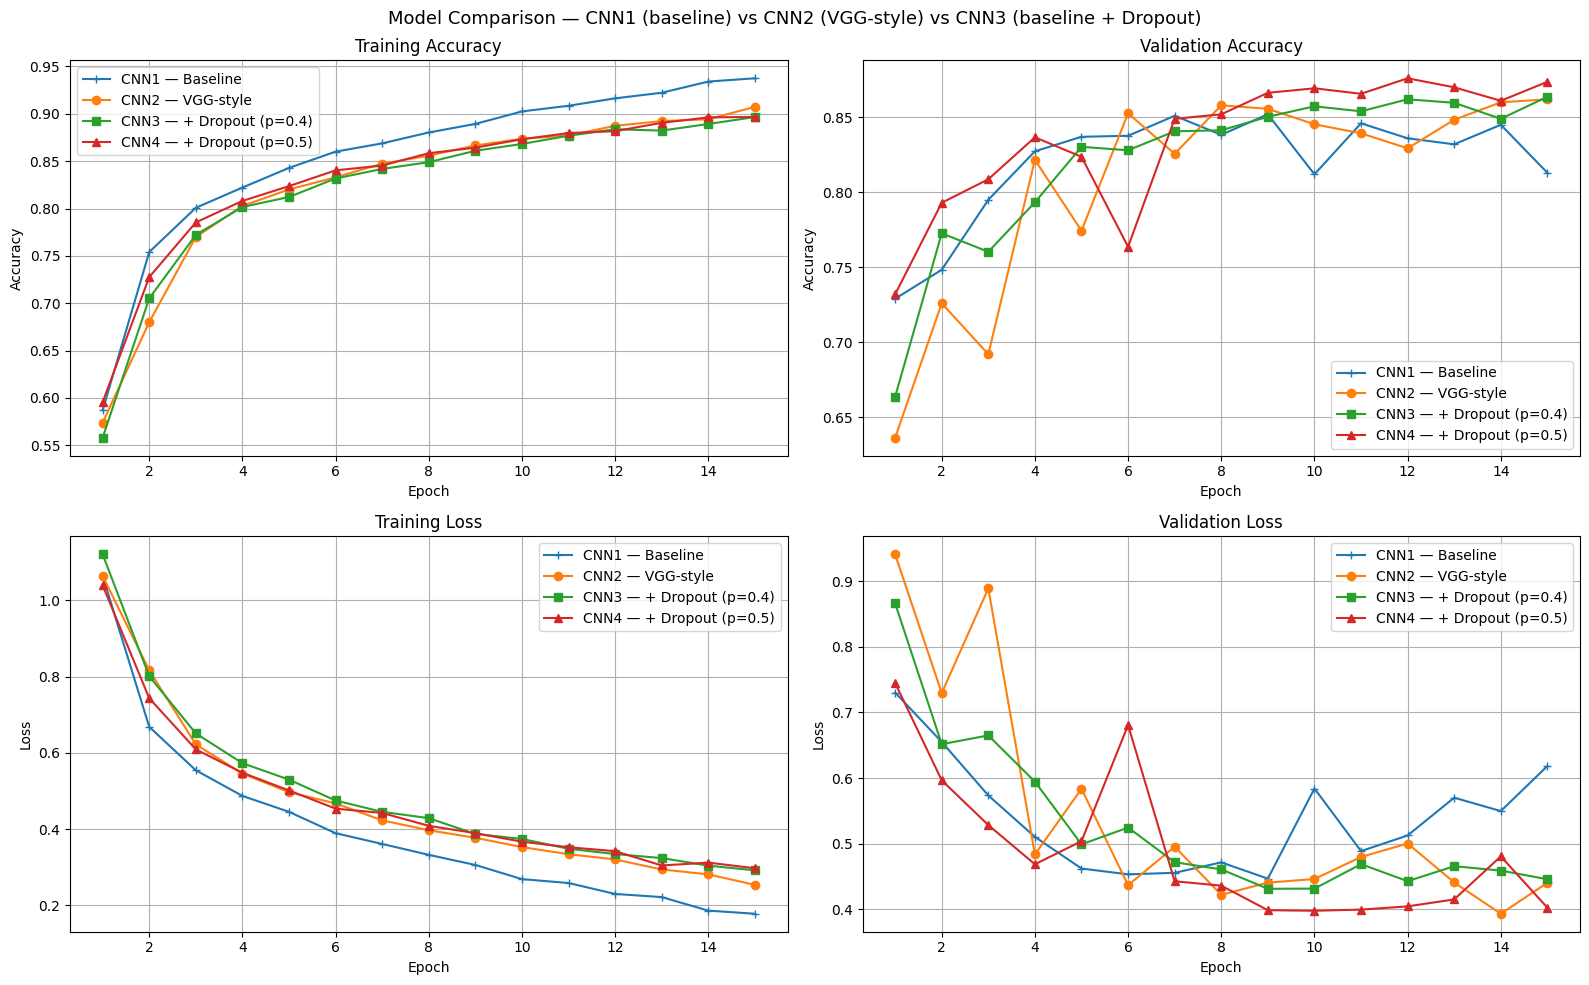

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "Model Comparison — CNN1 (baseline) vs CNN2 (VGG-style) vs CNN3 (baseline + Dropout)",
    fontsize=13
)

epochs_range = range(1, len(training_acc_1) + 1)

# Training Accuracy
ax = axes[0, 0]
ax.plot(epochs_range, training_acc_1, marker='+', label='CNN1 — Baseline')
ax.plot(epochs_range, training_acc_2, marker='o', label='CNN2 — VGG-style')
ax.plot(epochs_range, training_acc_3, marker='s', label='CNN3 — + Dropout (p=0.4)')
ax.plot(epochs_range, training_acc_4, marker='^', label='CNN4 — + Dropout (p=0.5)')
ax.set_title('Training Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)

# Validation Accuracy
ax = axes[0, 1]
ax.plot(epochs_range, validation_acc_1, marker='+', label='CNN1 — Baseline')
ax.plot(epochs_range, validation_acc_2, marker='o', label='CNN2 — VGG-style')
ax.plot(epochs_range, validation_acc_3, marker='s', label='CNN3 — + Dropout (p=0.4)')
ax.plot(epochs_range, validation_acc_4, marker='^', label='CNN4 — + Dropout (p=0.5)')
ax.set_title('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)

# Training Loss
ax = axes[1, 0]
ax.plot(epochs_range, training_loss_1, marker='+', label='CNN1 — Baseline')
ax.plot(epochs_range, training_loss_2, marker='o', label='CNN2 — VGG-style')
ax.plot(epochs_range, training_loss_3, marker='s', label='CNN3 — + Dropout (p=0.4)')
ax.plot(epochs_range, training_loss_4, marker='^', label='CNN4 — + Dropout (p=0.5)')
ax.set_title('Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# Validation Loss
ax = axes[1, 1]
ax.plot(epochs_range, validation_loss_1, marker='+', label='CNN1 — Baseline')
ax.plot(epochs_range, validation_loss_2, marker='o', label='CNN2 — VGG-style')
ax.plot(epochs_range, validation_loss_3, marker='s', label='CNN3 — + Dropout (p=0.4)')
ax.plot(epochs_range, validation_loss_4, marker='^', label='CNN4 — + Dropout (p=0.5)')
ax.set_title('Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [25]:
# Final summary — best validation accuracy per model

models_summary = [
    ('CNN1 — Baseline (single conv/block)',   max(validation_acc_1)),
    ('CNN2 — VGG-style (double conv/block)',  max(validation_acc_2)),
    ('CNN3 — Baseline + Dropout (p=0.4)',    max(validation_acc_3)),
    ('CNN4 — Baseline + Dropout (p=0.5)',    max(validation_acc_4)),
]

print(f"{'Model':<45} {'Best Val Acc':>12}")
print("-" * 60)
for name, acc in models_summary:
    print(f"{name:<45} {acc:>12.4f}")

Model                                         Best Val Acc
------------------------------------------------------------
CNN1 — Baseline (single conv/block)                 0.8520
CNN2 — VGG-style (double conv/block)                0.8620
CNN3 — Baseline + Dropout (p=0.4)                   0.8637
CNN4 — Baseline + Dropout (p=0.5)                   0.8760


In [26]:
# torch.save(cnn4.state_dict(), '/home/skandan-c-y/PycharmProjects/PyTorch/models/torch04_cnn4_state_dict.pth')